PyTorch version: 2.10.0+cpu
CUDA available: False

TRAINING NUMPY MODEL
Epoch 1
-------------------------------
loss: 2.300512  [   64/60000]
loss: 2.159739  [ 6464/60000]
loss: 1.804688  [12864/60000]
loss: 1.493211  [19264/60000]
loss: 1.126928  [25664/60000]
loss: 1.035107  [32064/60000]
loss: 1.011863  [38464/60000]
loss: 0.864091  [44864/60000]
loss: 0.868344  [51264/60000]
loss: 0.820786  [57664/60000]
Test Error: 
 Accuracy: 72.0%, Avg loss: 0.789212 

Epoch 2
-------------------------------
loss: 0.791673  [   64/60000]
loss: 0.849833  [ 6464/60000]
loss: 0.579616  [12864/60000]
loss: 0.782371  [19264/60000]
loss: 0.660372  [25664/60000]
loss: 0.628223  [32064/60000]
loss: 0.712872  [38464/60000]
loss: 0.680128  [44864/60000]
loss: 0.706288  [51264/60000]
loss: 0.646930  [57664/60000]
Test Error: 
 Accuracy: 78.3%, Avg loss: 0.631795 

Epoch 3
-------------------------------
loss: 0.564862  [   64/60000]
loss: 0.656809  [ 6464/60000]
loss: 0.436411  [12864/60000]
loss: 0.669556

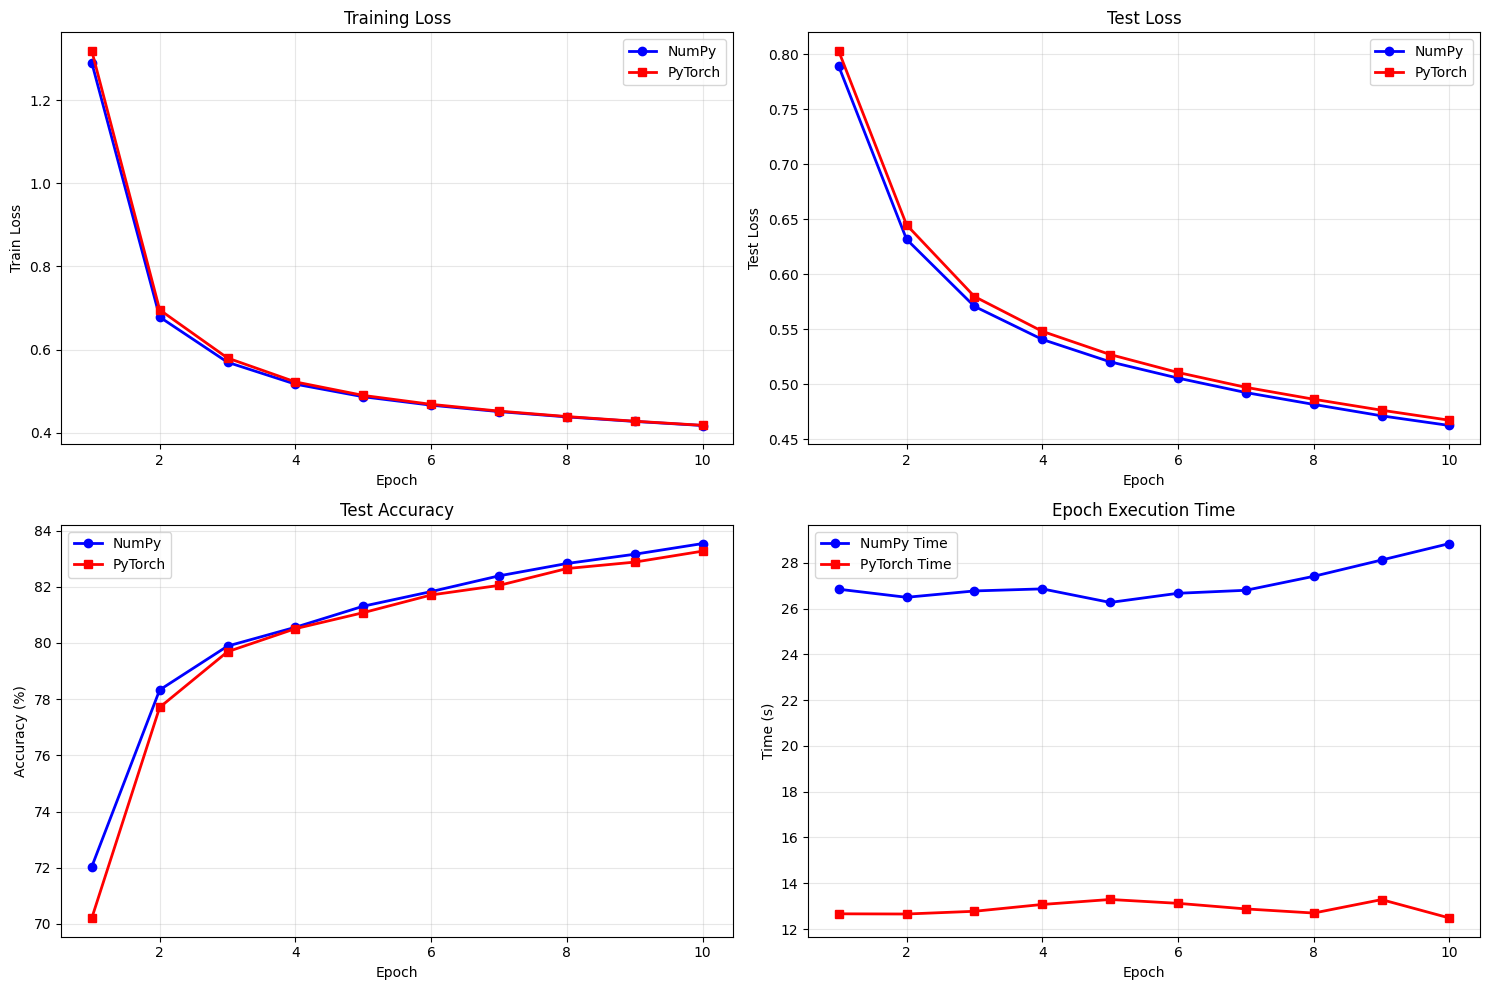


INFERENCE COMPARISON (First test sample)
Actual label:    Ankle boot
NumPy prediction: Ankle boot
PyTorch prediction: Ankle boot

PyTorch model saved to fashion_mnist_model.pth


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from PIL import Image
import time

# ==================== CONFIGURATION ====================
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-2 

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = "cuda" if torch.cuda.is_available() else "cpu"

# ==================== DATA LOADING ====================
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE)

classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# ==================== NUMPY ====================

class Linear:
    """Linear layer with Professor's initialization logic"""
    def __init__(self, in_features, out_features):
        # граница интервала k = 1 / sqrt(in_features)
        k = 1 / np.sqrt(in_features)

        self.weight = np.random.uniform(-k, k, size=(in_features, out_features)).astype(np.float32)
        self.bias = np.random.uniform(-k, k, size=(out_features,)).astype(np.float32)
        
        self.grad_weight = np.zeros_like(self.weight)
        self.grad_bias = np.zeros_like(self.bias)
        self.input = None

    def forward(self, x):
        self.input = x.astype(np.float32)
        return x @ self.weight + self.bias

    def backward(self, grad_output):

        self.grad_weight = self.input.T @ grad_output
        self.grad_bias = grad_output.sum(axis=0)
        grad_input = grad_output @ self.weight.T
        return grad_input


class ReLU:

    def __init__(self):
        self.input = None

    def forward(self, x):
        self.input = x
        return np.maximum(x, 0)

    def backward(self, grad_output):
        # dx = dy * (x > 0)
        return grad_output * (self.input > 0)


class CrossEntropyLossNumpy:

    def __init__(self):
        self.log_softmax = None
        self.y_true = None
        self.batch_size = None

    def forward(self, logits, y_true):

        m = np.max(logits, axis=1, keepdims=True)
        log_sum_exp = np.log(np.sum(np.exp(logits - m), axis=1, keepdims=True))
        log_softmax = logits - m - log_sum_exp
        
        # Сохраняем для backward
        self.log_softmax = log_softmax
        self.y_true = y_true
        self.batch_size = logits.shape[0]
        
        # Вычисляем Loss
        return -np.mean(log_softmax[np.arange(self.batch_size), y_true])

    def backward(self):
        # Градиент CrossEntropy
        probs = np.exp(self.log_softmax)
        num_classes = probs.shape[1]
        one_hot = np.eye(num_classes)[self.y_true]
        grad = (probs - one_hot) / self.batch_size
        return grad


class NeuralNetworkNumpy:
    def __init__(self):

        self.layers = [
            Linear(28*28, 512),
            ReLU(),
            Linear(512, 512),
            ReLU(),
            Linear(512, 10)
        ]

    def forward(self, x):
        # Flatten тут
        x = x.reshape(x.shape[0], -1)
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad_output):
        for layer in reversed(self.layers):
            grad_output = layer.backward(grad_output)
        return grad_output

    def update_params(self, lr):
        # Отдельный метод обновления
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.weight -= lr * layer.grad_weight
                layer.bias -= lr * layer.grad_bias


# ==================== NUMPY TRAINING & EVALUATION ====================

def train_numpy(dataloader, model, loss_fn, lr):
    size = len(dataloader.dataset)
    total_loss = 0
    
    # Цикл обучения
    for batch, (X, y) in enumerate(dataloader):
        X_np = X.numpy()
        y_np = y.numpy()

        # 1. Forward pass
        preds = model.forward(X_np)
        
        # 2. Loss Forward
        loss = loss_fn.forward(preds, y_np)
        total_loss += loss

        # 3. Loss Backward (получаем градиент от функции потерь)
        grad_output = loss_fn.backward()
        
        # 4. Model Backward (распространяем градиент по сети)
        model.backward(grad_output)
        
        # 5. Update Parameters (шаг оптимизатора)
        model.update_params(lr)

        # Логирование
        if batch % 100 == 0:
            current = (batch + 1) * len(X_np)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    return total_loss / len(dataloader)


def test_numpy(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    test_loss, correct = 0, 0

    for X, y in dataloader:
        X_np = X.numpy()
        y_np = y.numpy()

        preds = model.forward(X_np)
        # Считаем loss для статистики
        test_loss += loss_fn.forward(preds, y_np) * len(y_np)
        correct += np.sum(np.argmax(preds, axis=1) == y_np)

    test_loss /= size
    accuracy = correct / size
    print(f"Test Error: \n Accuracy: {(100 * accuracy):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, accuracy


# ==================== PYTORCH IMPLEMENTATION ====================

class NeuralNetworkPyTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.linear_relu_stack(x)


def train_pytorch(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        if batch % 100 == 0:
            current = (batch + 1) * len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")
    
    return total_loss / len(dataloader)


def test_pytorch(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    test_loss /= num_batches
    accuracy = 100 * correct / size
    print(f"Test Error: \n Accuracy: {accuracy:>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, accuracy


# ==================== TRAINING & EVALUATION LOOP ====================

print("\n" + "="*60)
print("TRAINING NUMPY MODEL")
print("="*60)

model_numpy = NeuralNetworkNumpy()
loss_fn_numpy = CrossEntropyLossNumpy()

history_numpy = {'train_loss': [], 'test_loss': [], 'test_acc': []}
numpy_times = []

for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    start_time = time.time()
    
    train_loss = train_numpy(train_dataloader, model_numpy, loss_fn_numpy, LR)
    test_loss, test_acc = test_numpy(test_dataloader, model_numpy, loss_fn_numpy)
    
    elapsed = time.time() - start_time
    numpy_times.append(elapsed)
    
    history_numpy['train_loss'].append(train_loss)
    history_numpy['test_loss'].append(test_loss)
    history_numpy['test_acc'].append(test_acc * 100) # В процентах для графика

print("NumPy training completed")

print("\n" + "="*60)
print("TRAINING PYTORCH MODEL")
print("="*60)

model_pytorch = NeuralNetworkPyTorch().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_pytorch.parameters(), lr=LR)

history_pytorch = {'train_loss': [], 'test_loss': [], 'test_acc': []}
torch_times = []

for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    start_time = time.time()

    train_loss = train_pytorch(train_dataloader, model_pytorch, loss_fn, optimizer)
    test_loss, test_acc = test_pytorch(test_dataloader, model_pytorch, loss_fn)
    
    elapsed = time.time() - start_time
    torch_times.append(elapsed)

    history_pytorch['train_loss'].append(train_loss)
    history_pytorch['test_loss'].append(test_loss)
    history_pytorch['test_acc'].append(test_acc)

print("PyTorch training completed")

# ==================== VISUALIZATION ====================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
epochs_range = range(1, EPOCHS + 1)

# Training loss comparison
axes[0, 0].plot(epochs_range, history_numpy['train_loss'], 'b-o', label='NumPy', linewidth=2)
axes[0, 0].plot(epochs_range, history_pytorch['train_loss'], 'r-s', label='PyTorch', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Train Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test loss comparison
axes[0, 1].plot(epochs_range, history_numpy['test_loss'], 'b-o', label='NumPy', linewidth=2)
axes[0, 1].plot(epochs_range, history_pytorch['test_loss'], 'r-s', label='PyTorch', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Test Loss')
axes[0, 1].set_title('Test Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy comparison
axes[1, 0].plot(epochs_range, history_numpy['test_acc'], 'b-o', label='NumPy', linewidth=2)
axes[1, 0].plot(epochs_range, history_pytorch['test_acc'], 'r-s', label='PyTorch', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Test Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Time comparison
axes[1, 1].plot(epochs_range, numpy_times, 'b-o', label='NumPy Time', linewidth=2)
axes[1, 1].plot(epochs_range, torch_times, 'r-s', label='PyTorch Time', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Time (s)')
axes[1, 1].set_title('Epoch Execution Time')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== INFERENCE DEMONSTRATION ====================

print("\n" + "="*60)
print("INFERENCE COMPARISON (First test sample)")
print("="*60)

x, y_true = test_data[0]
actual_class = classes[y_true]

# NumPy inference
x_np = x.numpy().reshape(1, 1, 28, 28)
logits_np = model_numpy.forward(x_np)
pred_np = classes[np.argmax(logits_np, axis=1)[0]]

# PyTorch inference
model_pytorch.eval()
with torch.no_grad():
    x_pt = x.unsqueeze(0).to(device)
    logits_pt = model_pytorch(x_pt)
    pred_pt = classes[logits_pt.argmax(1).item()]

print(f"Actual label:    {actual_class}")
print(f"NumPy prediction: {pred_np}")
print(f"PyTorch prediction: {pred_pt}")

# Save PyTorch model
torch.save(model_pytorch.state_dict(), "fashion_mnist_model.pth")
print("\nPyTorch model saved to fashion_mnist_model.pth")